<a href="https://colab.research.google.com/github/427paul/AI_Agent/blob/main/%5BBDA_8%EC%A3%BC%EC%B0%A8%5D_GPT%E1%84%86%E1%85%A9%E1%84%83%E1%85%A6%E1%86%AF_%E1%84%89%E1%85%B5%E1%86%AF%E1%84%89%E1%85%B3%E1%86%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 8주차 | GPT 모델 실습

> **선수지식**: 7주차(Self-Attention, Transformer Encoder)  
> **이번 목표**: GPT의 구조를 이해하고, 한국어 GPT 모델로 텍스트를 생성해본다

### 7주차 vs 8주차

```python
# 7주차: Encoder — 모든 단어를 양방향으로 참조 → 분류
# 8주차: Decoder — 왼쪽만 참조 (미래를 가림) → 생성
#
# 차이는 딱 하나: Attention에 마스크를 씌우는 것
```

| 파트 | 내용 |
|------|------|
| Part 1 | Causal Mask — "미래를 못 본다" |
| Part 2 | 미니 GPT 직접 만들기 |
| Part 3 | 한국어 GPT로 텍스트 생성 |
| Part 4 | 프롬프트 엔지니어링 |
| Part 5 | 8주 전체 정리 |

---
## Part 1. Causal Mask — GPT가 Encoder와 다른 점

7주차 Encoder에서는 모든 단어가 서로를 볼 수 있었습니다.  
GPT에서는 **삼각형 마스크**를 씌워서 미래 단어를 가립니다.  
왜? 텍스트를 생성할 때 미래 단어는 **아직 없으니까요.**

/tmp/ipykernel_4229/2964241196.py:33: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4229/2964241196.py:33: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4229/2964241196.py:33: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4229/2964241196.py:33: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4229/2964241196.py:33: UserWarning: Glyph 47484 (\N{HANGUL SYLLABLE REUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4229/2964241196.py:33: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4229/2964241196.py:33: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight

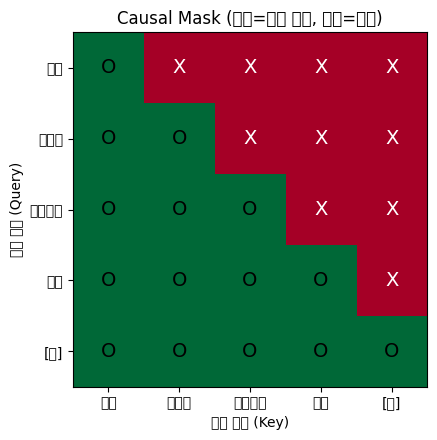

각 행은 자기보다 왼쪽(과거)만 참조 가능!
이것이 GPT가 텍스트를 '생성'할 수 있는 핵심 구조


In [1]:
# 1️⃣ Causal Mask 시각화
#
# 7주차 Encoder: 모든 칸이 O (양방향)
# 8주차 GPT:     아래 삼각형만 O (왼쪽만 참조)

import torch
import matplotlib.pyplot as plt

# 마스크 생성: 상삼각 부분 = True(가림)
seq_len = 5
mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()

tokens = ["나는", "영화를", "재미있게", "봤다", "[끝]"]

fig, ax = plt.subplots(figsize=(5, 4.5))
display = (~mask).float().numpy()  # O=초록, X=빨강
ax.imshow(display, cmap="RdYlGn", vmin=0, vmax=1)

ax.set_xticks(range(seq_len))
ax.set_yticks(range(seq_len))
ax.set_xticklabels(tokens, fontsize=10)
ax.set_yticklabels(tokens, fontsize=10)
ax.set_xlabel("참조 대상 (Key)")
ax.set_ylabel("현재 위치 (Query)")
ax.set_title("Causal Mask (초록=참조 가능, 빨강=가림)")

for i in range(seq_len):
    for j in range(seq_len):
        label = "O" if not mask[i][j] else "X"
        color = "black" if not mask[i][j] else "white"
        ax.text(j, i, label, ha="center", va="center", fontsize=14, color=color)

plt.tight_layout()
plt.show()

print("각 행은 자기보다 왼쪽(과거)만 참조 가능!")
print("이것이 GPT가 텍스트를 '생성'할 수 있는 핵심 구조")

---
## Part 2. 미니 GPT 직접 만들기

GPT의 사전학습 = **"다음 단어 예측"** 을 아주 작은 규모로 직접 만들어봅니다.

```
학습 방식:
  입력: "나는"           → 정답: "영화를"
  입력: "나는 영화를"     → 정답: "좋아한다"
```

> 7주차 Transformer 코드를 아는 분이라면,  
> 달라지는 부분은 **causal_mask 한 줄**과 **출력층**뿐입니다.

In [2]:
# 2️⃣ 학습 데이터 — 간단한 문장 4개
import torch
import torch.nn as nn

sentences = [
    "나는 영화를 좋아한다",
    "나는 음악을 좋아한다",
    "그는 영화를 싫어한다",
    "그는 음악을 싫어한다",
]

# 어휘 사전 만들기
all_tokens = sorted(set(w for s in sentences for w in s.split()))
word2idx = {w: i+1 for i, w in enumerate(all_tokens)}
word2idx["<PAD>"] = 0
idx2word = {i: w for w, i in word2idx.items()}

print(f"어휘 사전: {word2idx}")
print(f"총 {len(word2idx)}개 단어")

어휘 사전: {'그는': 1, '나는': 2, '싫어한다': 3, '영화를': 4, '음악을': 5, '좋아한다': 6, '<PAD>': 0}
총 7개 단어


In [4]:
# 3️⃣ "다음 단어 예측" 학습 쌍 만들기
#
# 예) "나는 영화를 좋아한다"에서:
#   입력: [나는]         → 정답: 영화를
#   입력: [나는, 영화를]  → 정답: 좋아한다

MAX_LEN = 4
X_train = []  # 입력 시퀀스
y_train = []  # 다음 단어 (정답)

for sent in sentences:
    tokens = [word2idx[w] for w in sent.split()]
    for i in range(1, len(tokens)):
        # 입력: 0~i-1번째 단어 (왼쪽 패딩)
        inp = tokens[:i]
        padded = [0] * (MAX_LEN - len(inp)) + inp
        X_train.append(padded)
        # 정답: i번째 단어
        y_train.append(tokens[i])

X_train = torch.tensor(X_train, dtype=torch.long)
y_train = torch.tensor(y_train, dtype=torch.long)

# 학습 데이터 확인
print(f"학습 샘플: {len(X_train)}개\n")
for i in range(min(6, len(X_train))):
    words_in = [idx2word[t.item()] for t in X_train[i] if t.item() != 0]
    word_out = idx2word[y_train[i].item()]
    print(f"  {str(words_in):30s} → {word_out}")

학습 샘플: 8개

  ['나는']                         → 영화를
  ['나는', '영화를']                  → 좋아한다
  ['나는']                         → 음악을
  ['나는', '음악을']                  → 좋아한다
  ['그는']                         → 영화를
  ['그는', '영화를']                  → 싫어한다


In [5]:
# 4️⃣ 미니 GPT 모델 정의
#
# 7주차 TransformerClassifier와 비교:
#   [같은 점] Embedding, TransformerEncoder 사용
#   [다른 점 1] causal_mask 추가 (미래를 가림)
#   [다른 점 2] 출력이 sigmoid(1개) 대신 vocab_size개 (다음 단어 확률)

import math

class MiniGPT(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers, max_len):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_emb = nn.Embedding(max_len, d_model)  # 위치 임베딩

        # Transformer (7주차와 같은 부품)
        layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=num_heads,
            dim_feedforward=d_model * 4,
            dropout=0.1, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers)

        # 출력: 어휘 크기만큼 (다음 단어의 확률 분포)
        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        B, T = x.shape

        # 임베딩 + 위치
        pos = torch.arange(T, device=x.device).unsqueeze(0)
        x = self.token_emb(x) + self.pos_emb(pos)

        # ★ 핵심 차이: Causal Mask (미래를 못 보게!)
        causal_mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()

        # Transformer 실행
        x = self.transformer(x, mask=causal_mask)

        # 마지막 위치 → 다음 단어 예측
        logits = self.fc_out(x[:, -1, :])  # (B, vocab_size)
        return logits


mini_gpt = MiniGPT(
    vocab_size=len(word2idx),
    d_model=32,     # 임베딩 차원
    num_heads=4,    # Attention 헤드 수
    num_layers=2,   # 블록 반복 수
    max_len=MAX_LEN
)
print(mini_gpt)
print(f"\n파라미터: {sum(p.numel() for p in mini_gpt.parameters()):,}개")

MiniGPT(
  (token_emb): Embedding(7, 32, padding_idx=0)
  (pos_emb): Embedding(4, 32)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc_out): Linear(in_features=32, out_features=7, bias=True)
)

파라미터: 25,991개


In [6]:
# 5️⃣ 미니 GPT 학습
#
# 학습 루프는 6~7주차와 같은 패턴!
# 차이: BCELoss(이진) → CrossEntropyLoss(다중 클래스)
#   → "다음 단어가 어휘 중 뭐냐" = 다중 분류 문제

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mini_gpt.parameters(), lr=0.005)

for epoch in range(200):
    mini_gpt.train()
    logits = mini_gpt(X_train)         # 1. 순전파
    loss = criterion(logits, y_train)  # 2. 손실
    optimizer.zero_grad()              # 3. 초기화
    loss.backward()                    # 4. 역전파
    optimizer.step()                   # 5. 업데이트

    if (epoch + 1) % 50 == 0:
        acc = (logits.argmax(dim=1) == y_train).float().mean()
        print(f"Epoch {epoch+1:3d} | Loss: {loss.item():.4f} | Acc: {acc.item():.0%}")

print("\n학습 완료!")

Epoch  50 | Loss: 0.3245 | Acc: 88%
Epoch 100 | Loss: 0.3692 | Acc: 75%
Epoch 150 | Loss: 0.3438 | Acc: 75%
Epoch 200 | Loss: 0.3342 | Acc: 88%

학습 완료!


In [8]:
# 6️⃣ 미니 GPT로 텍스트 생성!
#
# 자기회귀 생성: 한 단어씩 만들고, 만든 단어를 다시 입력에 추가

def generate(start_words, max_generate=3):
    """시작 단어들로부터 다음 단어를 하나씩 생성"""
    mini_gpt.eval()
    tokens = [word2idx.get(w, 0) for w in start_words]
    result = list(start_words)

    for _ in range(max_generate):
        padded = [0] * (MAX_LEN - len(tokens)) + tokens[-MAX_LEN:]
        inp = torch.tensor([padded], dtype=torch.long)

        with torch.no_grad():
            logits = mini_gpt(inp)
            next_id = logits.argmax(dim=1).item()  # 가장 확률 높은 단어

        if next_id == 0:
            break
        tokens.append(next_id)
        result.append(idx2word[next_id])

    return " ".join(result)


print("=== 미니 GPT 텍스트 생성 ===")
print()
print(f"  '나는'         → {generate(["나는"])}")
print(f"  '그는'         → {generate(["그는"])}")
print(f"  '나는 음악을'  → {generate(["나는", "음악을"])}")
print(f"  '그는 영화를'  → {generate(["그는", "영화를"])}")
print()
print("학습한 패턴대로 다음 단어를 예측합니다!")
print("이것이 GPT의 핵심 원리 — 규모만 수억 배 키운 것이 ChatGPT")

=== 미니 GPT 텍스트 생성 ===

  '나는'         → 나는 영화를 좋아한다 영화를
  '그는'         → 그는 영화를 싫어한다 영화를
  '나는 음악을'  → 나는 음악을 좋아한다 영화를 싫어한다
  '그는 영화를'  → 그는 영화를 싫어한다 영화를 싫어한다

학습한 패턴대로 다음 단어를 예측합니다!
이것이 GPT의 핵심 원리 — 규모만 수억 배 키운 것이 ChatGPT


---
## Part 3. 한국어 GPT로 진짜 텍스트 생성

위의 미니 GPT는 단어 6개짜리 장난감이었습니다.  
이제 **실제 사전학습된 한국어 GPT** 모델을 사용해봅시다.

`skt/kogpt2-base-v2`는 SKT에서 한국어 텍스트로 학습한 GPT-2 모델입니다.  
**무료**이고, Colab 무료 GPU로도 실행 가능합니다.

In [9]:
# 7️⃣ 설치 & 한국어 GPT 텍스트 생성
#
# Colab에서 실행하세요. 최초 실행 시 모델 다운로드에 1~2분 걸립니다.

# !pip install transformers

from transformers import pipeline

# 한국어 GPT-2 모델 로드
generator = pipeline(
    "text-generation",
    model="skt/kogpt2-base-v2",  # SKT 한국어 GPT-2
)

# 텍스트 생성
results = generator(
    "인공지능 기술이 발전하면",   # 시작 문장
    max_length=80,              # 최대 길이
    num_return_sequences=3,     # 3개 생성
    do_sample=True,             # 확률적 샘플링
    temperature=0.8,            # 창의성 조절
)

print("=== 한국어 GPT 텍스트 생성 ===")
for i, r in enumerate(results, 1):
    print(f"\n[생성 {i}]")
    print(r["generated_text"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/513M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/513M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer.json: 0.00B [00:00, ?B/s]

Passing `generation_config` together with generation-related arguments=({'max_length', 'temperature', 'do_sample', 'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=256) and `max_length`(=80) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== 한국어 GPT 텍스트 생성 ===

[생성 1]
인공지능 기술이 발전하면���v���n��v���n�u�n��n�r�▁)▁의▁약자다.
프랑스,▁오스트리아,▁독일▁등▁유럽▁국가들▁중엔▁약자지만,▁대부분▁약자다.
프랑스도▁약자다.
유럽▁국가들▁중에서▁'강자'라고▁불리는▁국가가▁약자다.
보통▁약자/강자▁관계는▁없지만,▁대부분의▁국가들▁중▁약자▁관계가▁가장▁많다.
2019년▁11월▁기준▁약자/강자▁관계는▁다음과▁같다
AFP▁통계에▁따르면▁2019년▁기준▁유럽▁약자/강자▁관계는▁약자로▁등재될▁만한▁수준이다.▁오디션▁방송에서▁출연하는▁멤버들의▁팬미팅이다.
이▁방송에서▁오디션▁방송이▁있을▁때▁오디션▁방송이▁끝나고▁오디션▁방송이▁끝나면▁파티가▁열린다.
오디션▁방송이▁끝나면▁파티는▁다시▁오디션▁방송을▁볼▁수▁있다.
오디션▁방송이▁끝나고▁파티가▁끝나면▁파티가▁끝나면▁파티가▁끝난▁후▁파티가▁끝난▁후▁멤버들과▁함께▁파티가▁끝난다.
파티에서▁받은▁오디션▁곡은▁1절에서▁따온▁것이다.
참고로▁멤버들도▁오디션▁방송을▁보러▁오는데,▁오디션▁방송에서▁한▁멤버가▁'오디션▁방송에서▁오디션▁방송을▁본▁것'▁같은▁착각을▁하는▁경우도▁종종▁있다.
이▁멤버가▁파티에

[생성 2]
인공지능 기술이 발전하면n�
▁(▁▁)
▁(▁▁)▁이▁장비는▁기존의▁버튼을▁모두▁제거하고▁터치스크린▁방식으로▁동작한다.
아래▁사진은▁위의▁내용을▁바탕으로▁작성한▁것이다.
장비는▁동작과▁동시에▁터치스크린의▁버튼을▁눌러,
왼손위▁버튼을▁눌러,
왼손위▁버튼을▁눌러,
오른손위▁버튼을▁눌러,
오른손위▁버튼을▁눌러,
왼손위▁버튼을▁눌러,
오른손위▁버튼을▁눌러,
오른손위▁버튼을▁눌러,
왼손위▁버튼을▁눌러,
오른손위▁버튼을▁눌러,
왼손위▁버튼을▁눌러,
오른손위▁버튼을▁눌러,
왼손위▁버튼을▁눌러,
왼손위▁버튼을▁눌러,
오른손위▁버튼을▁눌러,
왼손위▁버튼을▁눌러,
왼손위▁버

[생성 3]
인공지능 기술이 발전하면�t��n�n�n�n�n�n�n�n�n�n�n�n�n�n�n�n�n�n�n�n�n�n�n�n�n�n�n�n�n�n�n�n�n�n

In [11]:
# 8️⃣ Temperature 비교 — 창의성 조절
#
# temperature가 낮으면: 가장 확률 높은 단어만 선택 (안전, 반복적)
# temperature가 높으면: 다양한 단어도 선택 (창의적, 엉뚱할 수도)

prompt = "오늘 날씨가 좋아서"

print(f"프롬프트: '{prompt}'\n")

for temp in [0.3, 0.7, 1.2]:
    result = generator(
        prompt,
        max_length=60,
        do_sample=True,
        temperature=temp,
        num_return_sequences=1,
    )
    text = result[0]["generated_text"]
    print(f"Temperature={temp}:")
    print(f"  {text}")
    print()

print("0.3: 보수적, 예측 가능")
print("0.7: 적당한 다양성 (추천값)")
print("1.2: 창의적, 엉뚱할 수 있음")

Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


프롬프트: '오늘 날씨가 좋아서'



Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Temperature=0.3:
  오늘 날씨가 좋아서▁



Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Temperature=0.7:
  오늘 날씨가 좋아서�r�r��n�r�n�r�n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n�

Temperature=1.2:
  오늘 날씨가 좋아서š����š�ːː���,▁(▁▁)로▁바꾸니▁그▁동안▁너무▁큰▁소리▁나는▁거야.▁그▁소리는▁정말이지▁잘▁듣는데..."
그녀가▁이▁소리를▁듣고는,
나는▁그▁사실을▁기억할까.
'무슨▁소리!'
그가▁말한▁소리가▁나는▁거야.▁난▁아무데도▁말▁안▁하는데▁그▁소리가▁나는▁거야.▁내가▁말한▁소리가▁났으면▁얼마나▁좋을까?
그럴▁리가요.
나를▁다시▁본▁순간,▁그녀보다▁나이가▁많은▁사람이▁내게▁물었다.
"그건▁뭐죠?"
"아,▁그렇군요.▁당신께선▁이미,▁괜찮은▁사람이신데."
난▁내▁말을▁이해할▁수▁없다는▁듯이▁대답하며▁고개를▁저었다.
'왜▁그▁목소리가▁나게▁돼?'
그리고▁나서▁그녀는▁나를▁쳐다보았다.
나▁역시▁난▁무슨▁소리인지▁이해하지▁못했다.
그것은▁나▁자신으로▁말미암아▁더▁이상▁그런▁것이▁아니라는▁뜻이고,▁나의▁모든▁욕망은▁그녀가▁나에게▁가르쳐준▁것▁뿐이라는▁뜻이다.
'나는▁그녀가▁나를▁이해했던▁그▁많은▁순간들▁가운데▁나의▁욕망을▁이루는▁모든▁것들을▁완전히▁포기했다네.'.
나는▁그녀를▁생각하며▁말을▁이었다.
"내가▁가장▁좋아하는▁것들,▁모든▁걸▁빼앗아▁간▁모든▁것들을▁전부▁빼앗겼네.▁하지만▁그렇게▁되었어."
"난

0.3: 보수적, 예측 가능
0.7: 적당한 다양성 (추천값)
1.2: 창의적, 엉뚱할 수 있음


In [13]:
# 9️⃣ 다양한 프롬프트로 생성 실험
#
# 시작 문장에 따라 생성 결과가 어떻게 달라지는지 비교해봅시다.

prompts = [
    "대한민국의 수도는",
    "맛있는 음식을 먹으면",
    "프로그래밍을 배우려면",
    "행복한 삶을 위해서는",
]

print("=== 다양한 프롬프트 실험 ===\n")
for prompt in prompts:
    result = generator(
        prompt,
        max_length=50,
        do_sample=True,
        temperature=0.7,
        num_return_sequences=1,
    )
    print(f"입력: '{prompt}'")
    print(f"생성: {result[0]["generated_text"]}")
    print()

Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== 다양한 프롬프트 실험 ===



Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


입력: '대한민국의 수도는'
생성: 대한민국의 수도는�t��t�i�i�n��i�n�r��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n��n�



Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


입력: '맛있는 음식을 먹으면'
생성: 맛있는 음식을 먹으면����鉉��������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������������



Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


입력: '프로그래밍을 배우려면'
생성: 프로그래밍을 배우려면r▁(▁�▁)▁.
▁▁▁(▁▁▁▁)▁.
▁▁(▁▁▁)▁.
▁▁▁(▁▁▁▁▁)▁.
▁▁(▁▁▁)▁.
▁▁(▁▁)▁.
▁(▁▁)▁.
▁▁(▁

입력: '행복한 삶을 위해서는'
생성: 행복한 삶을 위해서는�▁(▁▁)▁,▁▁(▁▁)▁,▁▁(▁▁)▁,▁▁(▁▁)▁,▁▁(▁▁)▁.▁한국형▁게임.▁'드림캐스트'라는▁명칭으로▁출시되었다.
이▁게임은▁캐시▁아이템을▁얻기▁위해▁수많은▁플레이어가▁모이는▁게임이다.
드림캐스트와는▁달리▁게임▁플레이를▁하기▁위해▁수많은▁플레이어가▁모이는▁게임이다.
다만▁이▁게임은▁드림캐스트가▁아닌,▁그냥▁게임▁플레이를▁위한▁드림캐스트▁게임이다.
드림캐스트와▁비슷한▁게임도▁있으나▁게임에▁등장하는▁드림캐스트▁시리즈가▁드림캐스트▁시리즈이다.
아케이드판이▁출시되어▁있지만▁게임▁플레이를▁위해▁게임▁플레이를▁하는▁것은▁아니다.
드림캐스트는▁게임▁플레이를▁위해▁게임▁플레이를▁할▁수▁있는▁드림캐스트▁게임이다.
게임▁플레이만▁하는▁게임은▁아니다.
플레이어와▁드림캐스트는▁그▁자체가▁게임의▁재미를▁떨어뜨린다.
드림캐스트▁게임은▁이▁게임의▁가장▁큰▁문제점인▁플레이어의▁지루함을▁해결하는데▁중점을▁둔다.
플레이어들이▁서로▁다른▁플레이어를▁플레이했을▁때▁다른▁플레이어가▁플레이어를



---
## Part 4. 프롬프트 엔지니어링

GPT-3 이후 모델이 충분히 커지면, **학습 없이 질문만으로** 과제를 수행합니다.

> 💡 아래 프롬프트는 `skt/kogpt2`보다는 **ChatGPT나 Claude** 같은  
> 대형 모델에서 잘 작동합니다. 여기서는 "이렇게 설계한다"는 것을 경험합니다.

### Zero-shot vs Few-shot

```
Zero-shot: 예시 없이 바로 질문
  "이 리뷰의 감성은? 리뷰: 재미있다 → 감성:"

Few-shot: 예시를 몇 개 보여준 뒤 질문
  "리뷰: 최고! → 긍정
   리뷰: 별로 → 부정
   리뷰: 좋았다 → "
```

In [14]:
# 🔟 프롬프트 설계 실습
#
# 아래는 실제로 ChatGPT/Claude에서 사용할 수 있는 프롬프트입니다.
# 직접 수정해보고, ChatGPT에 입력해서 테스트해보세요!

# --- 1) 감성 분류 프롬프트 ---
prompt_sentiment = """
당신은 상품 리뷰 감성 분석 전문가입니다.
리뷰를 읽고 긍정/부정/중립 중 하나로 분류하세요.

예시:
리뷰: 품질 좋고 배송 빨라요 → 긍정
리뷰: 불량이고 환불 어렵다 → 부정
리뷰: 디자인은 좋은데 내구성이 약해요 → 중립

리뷰: 가격 대비 만족합니다 →
"""

# --- 2) 요약 프롬프트 ---
prompt_summary = """
다음 텍스트를 3줄로 요약하세요.
각 줄은 핵심 내용만 담아주세요.

텍스트: (여기에 긴 텍스트)

요약:
"""

# --- 3) 키워드 추출 프롬프트 ---
prompt_keyword = """
다음 텍스트에서 핵심 키워드 5개를 추출하세요.
쉼표로 구분하여 나열하세요.

텍스트: (여기에 텍스트)

키워드:
"""

print("=== 프롬프트 설계 예시 ===")
print()
print("[감성 분류 프롬프트]")
print(prompt_sentiment)
print("설계 핵심:")
print("  1. 역할 부여 (감성 분석 전문가)")
print("  2. 분류 기준 명시 (긍정/부정/중립)")
print("  3. Few-shot 예시 3개")
print("  4. 출력 형식 지정 (→ 뒤에 답변)")

=== 프롬프트 설계 예시 ===

[감성 분류 프롬프트]

당신은 상품 리뷰 감성 분석 전문가입니다.
리뷰를 읽고 긍정/부정/중립 중 하나로 분류하세요.

예시:
리뷰: 품질 좋고 배송 빨라요 → 긍정
리뷰: 불량이고 환불 어렵다 → 부정
리뷰: 디자인은 좋은데 내구성이 약해요 → 중립

리뷰: 가격 대비 만족합니다 →

설계 핵심:
  1. 역할 부여 (감성 분석 전문가)
  2. 분류 기준 명시 (긍정/부정/중립)
  3. Few-shot 예시 3개
  4. 출력 형식 지정 (→ 뒤에 답변)


In [15]:
# 1️⃣1️⃣ KoGPT로 Few-shot 프롬프트 시도
#
# kogpt2는 작은 모델이라 프롬프트 성능이 제한적입니다.
# "이런 식으로 프롬프트를 설계한다"는 것을 경험하는 데 의의가 있습니다.

prompt = """다음은 영화 리뷰의 감성 분류 예시입니다.

리뷰: 정말 재미있는 영화였다
감성: 긍정

리뷰: 시간 낭비였다
감성: 부정

리뷰: 배우 연기가 좋았다
감성:"""

result = generator(
    prompt,
    max_length=len(prompt.split()) + 10,
    do_sample=False,
    num_return_sequences=1,
)

print("=== Few-shot 프롬프트 테스트 (KoGPT2) ===")
print(result[0]["generated_text"][-50:])  # 마지막 50자만
print()
print("kogpt2는 소규모 모델이라 정확하지 않을 수 있습니다.")
print("GPT-4나 Claude에서는 이 프롬프트로 정확하게 응답합니다.")
print()
print("직접 ChatGPT(chat.openai.com)나 Claude(claude.ai)에")
print("위 프롬프트를 붙여넣어 테스트해보세요!")

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'max_length', 'do_sample', 'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=256) and `max_length`(=32) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== Few-shot 프롬프트 테스트 (KoGPT2) ===
.�.�.�.�.�.�.�.�.�.�.�.�.�.�.�.�.�.�.�.�.�.�.�.�.�

kogpt2는 소규모 모델이라 정확하지 않을 수 있습니다.
GPT-4나 Claude에서는 이 프롬프트로 정확하게 응답합니다.

직접 ChatGPT(chat.openai.com)나 Claude(claude.ai)에
위 프롬프트를 붙여넣어 테스트해보세요!


---
## Part 5. 8주 전체 정리

### GPT 핵심 요약

```
GPT = Transformer + Causal Mask + 다음 단어 예측

7주차 Encoder:  양방향 참조 → 분류 (BERT)
8주차 Decoder:  왼쪽만 참조 → 생성 (GPT)

코드 차이: mask 한 줄 + 출력층 변경
```

### 세 가지 패러다임

```
패러다임 1: TF-IDF + ML         사람이 특성 설계    (1~5주차)
패러다임 2: 사전학습 + 파인튜닝   모델이 언어를 배움  (6~8주차)
패러다임 3: 프롬프트              질문만으로 해결     (GPT-3 이후)
```

### 8주간의 여정

```
[1주차] 입문
[2주차] 전처리            "텍스트를 깨끗하게"
[3주차] BoW, TF-IDF       "텍스트를 숫자로"
[4주차] ML 분류            "숫자로 분류"
[5주차] Word2Vec           "단어에 의미를"
[6주차] RNN, LSTM          "순서를 이해"
[7주차] Transformer        "문맥을 이해"
[8주차] GPT                "사전학습의 힘"
```

### 방법론 선택

| 상황 | 추천 |
|------|------|
| 데이터 적고 빠르게 | TF-IDF + ML |
| 순서 중요 | LSTM |
| 최고 성능 | BERT/GPT 파인튜닝 |
| 데이터 없음 | 프롬프트 (GPT API) |

---
## 📝 과제

### 과제 1: 한국어 GPT 텍스트 생성

다양한 시작 문장과 temperature로 텍스트를 생성하고 결과를 비교하세요.

### 과제 2: 프롬프트 설계

ChatGPT 또는 Claude에서 아래 3가지를 프롬프트로 해결하세요:
1. 감성 분류 (긍정/부정/중립)
2. 텍스트 요약 (3줄)
3. 키워드 추출 (5개)

각 과제: 프롬프트 설계 → 테스트 → 개선 과정을 기록하세요.